In [ ]:
import pandas as pd

from google.colab import files
uploaded = files.upload()

df = pd.read_csv('Brazilian E-Commerce Public Dataset by Olist.csv')
df.head()
df.info()
df.describe()

Saving Brazilian E-Commerce Public Dataset by Olist.csv to Brazilian E-Commerce Public Dataset by Olist (1).csv
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113390 entries, 0 to 113389
Data columns (total 39 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Unnamed: 0                     113390 non-null  int64  
 1   order_id                       113390 non-null  object 
 2   order_item_id                  113390 non-null  int64  
 3   customer_id                    113390 non-null  object 
 4   customer_unique_id             113390 non-null  object 
 5   customer_zip_code_prefix       113390 non-null  int64  
 6   customer_city                  113390 non-null  object 
 7   customer_state                 113390 non-null  object 
 8   product_id                     113390 non-null  object 
 9   product_category_name          113390 non-null  object 
 10  product_name_lenght            113390 no

,Unnamed: 0,order_item_id,customer_zip_code_prefix,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,seller_zip_code_prefix,payment_sequential,payment_installments,price,freight_value,payment_value,year_of_purchase
count,113390.000000,113390.000000,113390.000000,113390.000000,113390.000000,113390.000000,113390.000000,113390.000000,113390.000000,113390.000000,113390.000000,113390.000000,113390.000000,113390.000000,113390.000000,113390.000000,113390.000000
mean,56694.500000,1.196843,35080.723027,48.801755,785.793059,2.209375,2110.641917,30.281665,16.618635,23.099427,24510.930117,1.089937,2.942367,120.184057,20.023985,172.241850,2017.542588
std,32733.017849,0.701270,29844.853275,10.018253,650.986313,1.720293,3770.379971,16.160708,13.447915,11.740315,27636.230916,0.682057,2.777802,182.761548,15.752500,266.596347,0.504081
min,0.000000,1.000000,1003.000000,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000,1001.000000,1.000000,0.000000,0.850000,0.000000,0.000000,2016.000000
25%,28347.250000,1.000000,11320.000000,42.000000,346.000000,1.000000,300.000000,18.000000,8.000000,15.000000,6429.000000,1.000000,1.000000,39.900000,13.080000,61.000000,2017.000000
50%,56694.500000,1.000000,24325.000000,52.000000,601.000000,1.000000,700.000000,25.000000,13.000000,20.000000,13660.000000,1.000000,2.000000,74.900000,16.320000,108.140000,2018.000000
75%,85041.750000,1.000000,58768.750000,57.000000,985.000000,3.000000,1800.000000,38.000000,20.000000,30.000000,28495.000000,1.000000,4.000000,133.732500,21.200000,189.370000,2018.000000
max,113389.000000,21.000000,99980.000000,76.000000,3992.000000,20.000000,40425.000000,105.000000,105.000000,118.000000,99730.000000,26.000000,24.000000,6735.000000,409.680000,13664.080000,2018.000000


**DATA CLEANING**

In [ ]:
df.drop(columns=['Unnamed: 0'], inplace = True)

date_columns = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date',
    'shipping_limit_date'
]

for col in date_columns:
    df[col] = pd.to_datetime(df[col])

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113390 entries, 0 to 113389
Data columns (total 38 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       113390 non-null  object        
 1   order_item_id                  113390 non-null  int64         
 2   customer_id                    113390 non-null  object        
 3   customer_unique_id             113390 non-null  object        
 4   customer_zip_code_prefix       113390 non-null  int64         
 5   customer_city                  113390 non-null  object        
 6   customer_state                 113390 non-null  object        
 7   product_id                     113390 non-null  object        
 8   product_category_name          113390 non-null  object        
 9   product_name_lenght            113390 non-null  float64       
 10  product_description_lenght     113390 non-null  float64       
 11  

**FEATURE ENGINEERING**

In [ ]:
# 1 Extract year and month
df['order_year'] = df['order_purchase_timestamp'].dt.year
df['order_month'] = df['order_purchase_timestamp'].dt.month
df['order_month_year'] = df['order_purchase_timestamp'].dt.to_period('M')

# 2 Delivery time(in days)
df['delivery_days'] = (
    df['order_delivered_customer_date'] - df['order_purchase_timestamp']).dt.days

# 3 Delivery delay(diff between actual & estimated delivery)
df['delivery_delay']=(
    df['order_delivered_customer_date'] - df['order_estimated_delivery_date']).dt.days

# 4 Total order value (price + freight)
df['total_order_value'] = df['price'] + df['freight_value']

df.head()

,order_id,order_item_id,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,product_id,product_category_name,product_name_lenght,...,year_of_purchase,month/year_of_purchase,order_status,order_unique_id,order_year,order_month,order_month_year,delivery_days,delivery_delay,total_order_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,3ce436f183e68e07877b285a838db11a,871766c5855e863f6eccc05f988b23cb,28013,campos dos goytacazes,RJ,4244733e06e7ecb4970a6e2683c13e61,cool_stuff,58.0,...,2017,September-2017,delivered,00010242fe8c5a6d1ba2dd792cb16214-1,2017,9,2017-09,7,-9,72.19
1,130898c0987d1801452a8ed92a670612,1,e6eecc5a77de221464d1c4eaff0a9b64,0fb8e3eab2d3e79d92bb3fffbb97f188,75800,jatai,GO,4244733e06e7ecb4970a6e2683c13e61,cool_stuff,58.0,...,2017,June-2017,delivered,130898c0987d1801452a8ed92a670612-1,2017,6,2017-06,15,-13,73.86
2,532ed5e14e24ae1f0d735b91524b98b9,1,4ef55bf80f711b372afebcb7c715344a,3419052c8c6b45daf79c1e426f9e9bcb,30720,belo horizonte,MG,4244733e06e7ecb4970a6e2683c13e61,cool_stuff,58.0,...,2018,May-2018,delivered,532ed5e14e24ae1f0d735b91524b98b9-1,2018,5,2018-05,17,-3,83.23
3,6f8c31653edb8c83e1a739408b5ff750,1,30407a72ad8b3f4df4d15369126b20c9,e7c828d22c0682c1565252deefbe334d,83070,sao jose dos pinhais,PR,4244733e06e7ecb4970a6e2683c13e61,cool_stuff,58.0,...,2017,August-2017,delivered,6f8c31653edb8c83e1a739408b5ff750-1,2017,8,2017-08,8,-16,75.07
4,7d19f4ef4d04461989632411b7e588b9,1,91a792fef70ecd8cc69d3c7feb3d12da,0bb98ba72dcc08e95f9d8cc434e9a2cc,36400,conselheiro lafaiete,MG,4244733e06e7ecb4970a6e2683c13e61,cool_stuff,58.0,...,2017,August-2017,delivered,7d19f4ef4d04461989632411b7e588b9-1,2017,8,2017-08,13,-8,72.19


In [ ]:
print("Total Revenue:", df['total_order_value'].sum())
print("Total Orders:", df['order_id'].nunique())
print("Average Order Value:", df['total_order_value'].mean())

Total Revenue: 15898189.879999999
Total Orders: 95128
Average Order Value: 140.2080419790105


In [ ]:
# Delivery performance summary
print("Average Delivery Days:", df['delivery_days'].mean())
print("Average Delivery Delay:", df['delivery_delay'].mean())

# Percentage late deliveries
late_orders = df[df['delivery_delay']>0]
print("Late Delivery Percentage:", len(late_orders)/len(df)*100)

Average Delivery Days: 12.014622100714348
Average Delivery Delay: -12.04935179469089
Late Delivery Percentage: 6.533203986242173


**REVENUE TREND ANALYSIS**

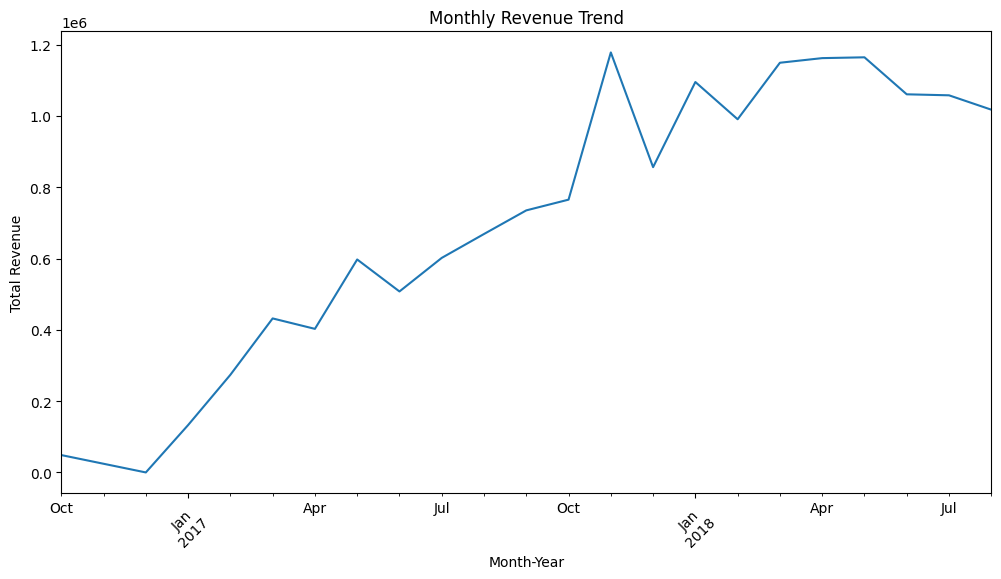

In [ ]:
import matplotlib.pyplot as plt

# Monthly revenue trend
monthly_revenue = df.groupby('order_month_year')['total_order_value'].sum()

plt.figure(figsize=(12,6))
monthly_revenue.plot()
plt.title("Monthly Revenue Trend")
plt.xlabel("Month-Year")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.show()


In [ ]:
# Revenue by Year
yearly_revenue = df.groupby('order_year')['total_order_value'].sum()
print(yearly_revenue)

order_year
2016      48761.49
2017    7151850.63
2018    8697577.76
Name: total_order_value, dtype: float64


In [ ]:
# Top 10 States by Revenue
top_states = df.groupby('customer_state')['total_order_value'].sum().sort_values(ascending=False).head(10)
print(top_states)

customer_state
SP    5963240.66
RJ    2131702.23
MG    1861444.43
RS     891820.64
PR     799401.12
BA     614639.82
SC     606332.41
DF     354934.23
GO     341756.54
ES     326180.47
Name: total_order_value, dtype: float64


In [ ]:
# Top 10 Product Categories
top_categories = df.groupby('product_category_name')['total_order_value'].sum().sort_values(ascending=False).head(10)
print(top_categories)

product_category_name
beleza_saude              1456150.76
relogios_presentes        1315013.93
cama_mesa_banho           1292422.04
esporte_lazer             1159673.97
informatica_acessorios    1068666.04
moveis_decoracao           922629.26
utilidades_domesticas      798858.27
cool_stuff                 719293.84
automotivo                 696377.68
ferramentas_jardim         593677.82
Name: total_order_value, dtype: float64


**Repeat Customer Analysis**

In [ ]:
# count orders per customer
customer_orders = df.groupby('customer_unique_id')['order_id'].nunique()

# identify repeat customers
repeat_customers = customer_orders[customer_orders>1]
repeat_rate = len(repeat_customers)/len(customer_orders)*100
print("Repeat Customer Rate:", repeat_rate)


Repeat Customer Rate: 2.976727012087184


**RFM TABLE**

In [ ]:
import datetime as dt
# Set ref date (latest purchase date)
snapshot_date = df['order_purchase_timestamp'].max() + dt.timedelta(days=1)

rfm = df.groupby('customer_unique_id').agg({
    'order_purchase_timestamp': lambda x: (snapshot_date - x.max()).days,
    'order_id': 'nunique',
    'total_order_value': 'sum'})
rfm.columns = ['Recency', 'Frequency', 'Monetary']
rfm.head()

,Recency,Frequency,Monetary
customer_unique_id,,,
0000366f3b9a7992bf8c76cfdf3221e2,112,1,141.90
0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,27.19
0000f46a3911fa3c0805444483337064,537,1,86.22
0000f6ccb0745a6a4b88665a16c9f078,321,1,43.62
0004aac84e0df4da2b147fca70cf8255,288,1,196.89


In [ ]:
# Create quartile scores (1 to 4)

rfm['R_score'] = pd.qcut(rfm['Recency'], 4, labels=[4,3,2,1])
rfm['F_score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 4, labels=[1,2,3,4])
rfm['M_score'] = pd.qcut(rfm['Monetary'], 4, labels=[1,2,3,4])

# Convert to int
rfm['R_score'] = rfm['R_score'].astype(int)
rfm['F_score'] = rfm['F_score'].astype(int)
rfm['M_score'] = rfm['M_score'].astype(int)

# Create combined RFM score
rfm['RFM_Score'] = (
    rfm['R_score'].astype(str) +
    rfm['F_score'].astype(str) +
    rfm['M_score'].astype(str)
)

rfm.head()

,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score
customer_unique_id,,,,,,,
0000366f3b9a7992bf8c76cfdf3221e2,112,1,141.90,4,1,3,413
0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,27.19,3,1,1,311
0000f46a3911fa3c0805444483337064,537,1,86.22,1,1,2,112
0000f6ccb0745a6a4b88665a16c9f078,321,1,43.62,2,1,1,211
0004aac84e0df4da2b147fca70cf8255,288,1,196.89,2,1,4,214


In [ ]:
rfm['RFM_Score'].value_counts().head(10)

,count
RFM_Score,
444,1766
344,1663
244,1599
232,1563
122,1544
144,1537
121,1531
423,1530
421,1527


In [ ]:
def segment_customers(row):
    if row['R_score'] >= 3 and row['F_score'] >= 3 and row['M_score'] >= 3:
        return 'Champions'
    elif row['F_score'] >= 3 and row['M_score'] >= 3:
        return 'Loyal Customers'
    elif row['R_score'] <= 2 and row['F_score'] >= 3:
        return 'At Risk'
    else:
        return 'Others'

rfm['Segment'] = rfm.apply(segment_customers, axis=1)

rfm['Segment'].value_counts()

,count
Segment,
Others,57128
Champions,12052
Loyal Customers,11465
At Risk,11436


In [ ]:
# merge segment info back to original dataframe
df = df.merge(rfm['Segment'], on='customer_unique_id', how='left')
df.head()

,order_id,order_item_id,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,product_id,product_category_name,product_name_lenght,...,month/year_of_purchase,order_status,order_unique_id,order_year,order_month,order_month_year,delivery_days,delivery_delay,total_order_value,Segment
0,00010242fe8c5a6d1ba2dd792cb16214,1,3ce436f183e68e07877b285a838db11a,871766c5855e863f6eccc05f988b23cb,28013,campos dos goytacazes,RJ,4244733e06e7ecb4970a6e2683c13e61,cool_stuff,58.0,...,September-2017,delivered,00010242fe8c5a6d1ba2dd792cb16214-1,2017,9,2017-09,7,-9,72.19,At Risk
1,130898c0987d1801452a8ed92a670612,1,e6eecc5a77de221464d1c4eaff0a9b64,0fb8e3eab2d3e79d92bb3fffbb97f188,75800,jatai,GO,4244733e06e7ecb4970a6e2683c13e61,cool_stuff,58.0,...,June-2017,delivered,130898c0987d1801452a8ed92a670612-1,2017,6,2017-06,15,-13,73.86,Others
2,532ed5e14e24ae1f0d735b91524b98b9,1,4ef55bf80f711b372afebcb7c715344a,3419052c8c6b45daf79c1e426f9e9bcb,30720,belo horizonte,MG,4244733e06e7ecb4970a6e2683c13e61,cool_stuff,58.0,...,May-2018,delivered,532ed5e14e24ae1f0d735b91524b98b9-1,2018,5,2018-05,17,-3,83.23,Others
3,6f8c31653edb8c83e1a739408b5ff750,1,30407a72ad8b3f4df4d15369126b20c9,e7c828d22c0682c1565252deefbe334d,83070,sao jose dos pinhais,PR,4244733e06e7ecb4970a6e2683c13e61,cool_stuff,58.0,...,August-2017,delivered,6f8c31653edb8c83e1a739408b5ff750-1,2017,8,2017-08,8,-16,75.07,At Risk
4,7d19f4ef4d04461989632411b7e588b9,1,91a792fef70ecd8cc69d3c7feb3d12da,0bb98ba72dcc08e95f9d8cc434e9a2cc,36400,conselheiro lafaiete,MG,4244733e06e7ecb4970a6e2683c13e61,cool_stuff,58.0,...,August-2017,delivered,7d19f4ef4d04461989632411b7e588b9-1,2017,8,2017-08,13,-8,72.19,Others


In [ ]:
df.to_csv("ecommerce_cleaned.csv", index=False)

In [ ]:
from google.colab import files
files.download("ecommerce_cleaned.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>